In [1]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [2]:
model = tf.keras.models.load_model(
    "../models/brain_tumor_classifier.keras"
)

In [3]:
TEST_DIR = "../datasets/classification/Testing"

IMG_SIZE = (128,128)

BATCH_SIZE = 32

In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [5]:
class_names = test_ds.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

test_ds = test_ds.map(
    lambda x,y:
    (
        normalization_layer(x),
        y
    )
)

In [7]:
y_true = np.concatenate(
    [y for x,y in test_ds],
    axis=0
)

predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [8]:
test_loss, test_accuracy = model.evaluate(
    test_ds
)

print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6744 - loss: 0.8912
Test Accuracy: 0.6743749976158142


In [9]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.70      0.56      0.62       400
  meningioma       0.50      0.45      0.47       400
     notumor       0.67      0.92      0.77       400
   pituitary       0.82      0.78      0.80       400

    accuracy                           0.67      1600
   macro avg       0.67      0.67      0.67      1600
weighted avg       0.67      0.67      0.67      1600



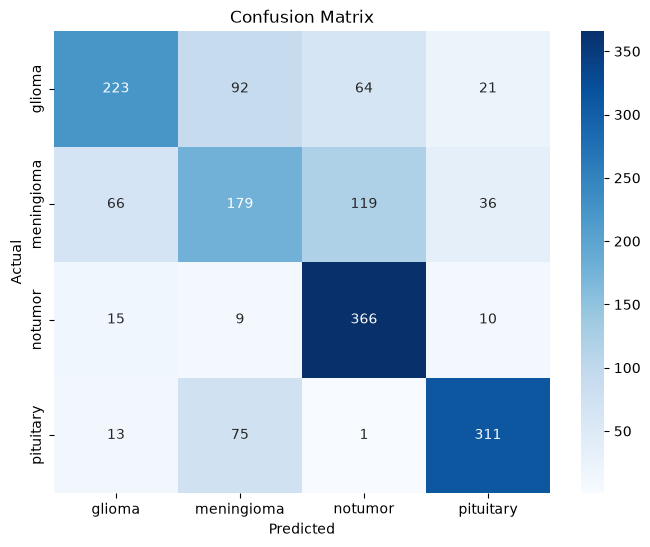

In [10]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()